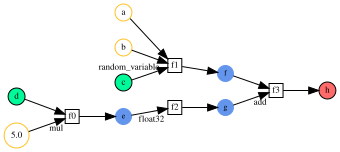

In [262]:
import jax 
import jax.numpy as jnp
import jax.random as jrandom

from jax import core
from jax import lax
from jax._src.util import safe_map

from probjax.core.random_variable import rv, rv_p
import matplotlib.pyplot as plt
from probjax.distributions import Normal

p = Normal(jnp.zeros(1), jnp.ones(1))
noise = rv(p, "noise")
def f(key, theta):
    x = 5.*theta + noise(key)
    return x

jaxpr = jax.make_jaxpr(f)(jrandom.PRNGKey(0), jnp.ones(2))
from probjax.core.graph import JaxprGraph
from probjax.core.transformations import joint_sample
import networkx as nx
jaxpr = jax.make_jaxpr(f)(1.,2.)
g = JaxprGraph(jaxpr.jaxpr.invars, jaxpr.jaxpr.constvars, jaxpr.jaxpr.outvars, jaxpr.jaxpr.eqns)
g

In [263]:
joint_simulator = joint_sample(f)

In [265]:
x_dim = 1
theta_dim = 1
prior = Normal(0., 10.)
thetas = prior.sample(jrandom.PRNGKey(0), (10000,))
xs, latent= jax.vmap(joint_simulator)(jrandom.split(jrandom.PRNGKey(0), 10000), thetas)
latent = latent["noise"]

In [292]:
params = {"m": 0., "s": 1.}
import distrax

def f_inverse(params, key, x):
    noise = x*params["m"] + params["s"]**2*jrandom.normal(key, x.shape)
    z = x - noise
    return z/5. , noise

In [293]:

def loss_fn(params, x):
    theta_inv, noise = jax.vmap(f_inverse, in_axes=(None, 0,0))(params, jrandom.split(jrandom.PRNGKey(0), x.shape[0]), x)
    log_prob = jnp.mean(distrax.Normal(0.,1.).log_prob(theta_inv))
    return -log_prob

In [294]:
def log_potential(theta,x):
    z = theta*5
    return Normal(z,1.).log_prob(x) + Normal(0.,1.).log_prob(theta)

# 1) Train: Fit the marginal distirbution over theta to the prior!



In [295]:
import optax

optimizer = optax.adam(1e-2)
initial_params = params
initial_opt_state = optimizer.init(params)

@jax.jit
def step(params, opt_state, x):
    grads = jax.grad(loss_fn)(params, x)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state


def train(params, opt_state, x, num_steps):
    for _ in range(num_steps):
        params, opt_state = step(params, opt_state, x)
    return params, opt_state


params, opt_state = train(initial_params, initial_opt_state, xs, 500)
params

{'m': Array(0.9999982, dtype=float32), 's': Array(0.07004184, dtype=float32)}

In [296]:
loss(params, jrandom.split(jrandom.PRNGKey(0)), xs[:2])

Array(-1260.4198, dtype=float32)

In [297]:
params

{'m': Array(0.9999982, dtype=float32), 's': Array(0.07004184, dtype=float32)}

In [298]:
x = jnp.linspace(-10,10,1000)
unnormalized_posterior =jnp.exp(jax.vmap(log_potential)(x, jnp.ones(1000)*x_o))
posterior = unnormalized_posterior / jnp.trapz(unnormalized_posterior, x)


In [299]:
thetas_post, noise = jax.vmap(f_inverse, in_axes=(None, 0,None))(params, jrandom.split(jrandom.PRNGKey(0), 10000), x_o)

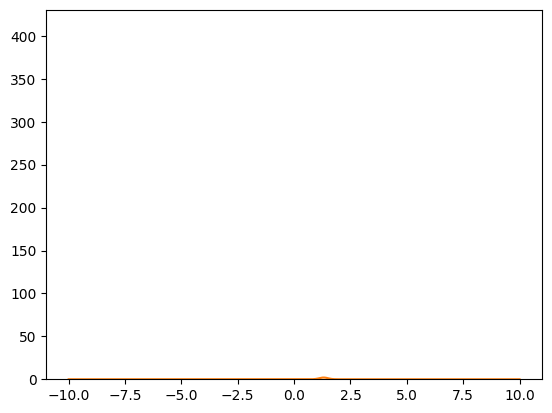

In [300]:
_ = plt.hist(jnp.squeeze(thetas_post), bins=50, density=True, alpha=0.5)
plt.plot(x, posterior)